# S_CattleMovementNetwork — USAMMv3 dairy cattle movement networks

Generates two layout options for visualizing mean cattle movement across 1,000 USAMMv3 network realizations, colored by season:

- **Option 1**: Single overlay map (all 4 seasons on one map)
- **Option 2**: 1×4 small multiples (one season per panel)

Each option has Panel A (county-level) and Panel B (state-level).

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import networkx as nx
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

In [2]:
PROJ_ROOT = Path('../..').resolve()
FINAL_DIR = PROJ_ROOT / 'paper' / 'final'
PAPER_DIR = PROJ_ROOT / 'paper'
FIG_DIR = FINAL_DIR / 'figures'
LEGACY_FIG_DIR = PAPER_DIR / 'figures'

RAW_DIR = PROJ_ROOT / 'analysis' / 'H5N1-Simulations-and-Analysis' / 'data' / 'raw'
EDIT_DIR = PROJ_ROOT / 'analysis' / 'H5N1-State-and-County-Simulations-and-Analysis_edit' / 'data'

NETWORK_DIR = FINAL_DIR / 'data' / 'networks' / 'dairy'
COUNTY_SHP = RAW_DIR / 'gadm41_USA_shp' / 'gadm41_USA_2.shp'
STATE_SHP = RAW_DIR / 'gadm41_USA_shp' / 'gadm41_USA_1.shp'
FLAPS_FILE = EDIT_DIR / 'cattle_FLAPS_for_USAMMv3.txt'
FIPS_FILE = RAW_DIR / 'US_FIPS_Codes_formatted.csv'
SCENARIO_FILE = LEGACY_FIG_DIR / 'all_county_origins' / 'scenario_summary.csv'

NUM_NETWORKS = 1000

In [3]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

In [4]:
SEASONS = {
    'Winter': (336, 60),
    'Spring': (61, 152),
    'Summer': (153, 244),
    'Autumn': (245, 335),
}
SEASON_ORDER = ['Winter', 'Spring', 'Summer', 'Autumn']

SEASON_COLORS = {
    'Winter': '#1F2A44',
    'Spring': '#1FA187',
    'Summer': '#C83E3A',
    'Autumn': '#D18F2F',
}

EDGE_ALPHA = 0.6
EDGE_CURVATURE = 0.75
NODE_COLOR = '#888888'

C_DAIRY = '#DDDBD6'
C_NON_DAIRY = '#F6F6F4'
MAP_BG = '#F6F6F4'
STATE_EDGE_COLOR = '#4A4A4A'
STATE_EDGE_LW = 0.6
COUNTY_EDGE_COLOR = '#cccccc'
COUNTY_EDGE_LW = 0.15

XLIM = (-125, -66)
YLIM = (24, 50)

## Load shapefiles and node positions

In [5]:
states_gdf = gpd.read_file(STATE_SHP)
states_gdf = states_gdf.cx[XLIM[0]:XLIM[1], YLIM[0]:YLIM[1]]

counties_gdf = gpd.read_file(COUNTY_SHP)
counties_gdf = counties_gdf.cx[XLIM[0]:XLIM[1], YLIM[0]:YLIM[1]]

flaps = pd.read_csv(FLAPS_FILE, sep='\t')
node_positions = {}
for _, row in flaps.iterrows():
    fips = int(row['County'])
    if fips not in node_positions:
        node_positions[fips] = (row['Lon'], row['Lat'])

fips_df = pd.read_csv(FIPS_FILE)
fips_to_state = {}
for _, row in fips_df.iterrows():
    fips_to_state[int(row['fips'])] = row['state']

def norm(s):
    s = str(s).strip().lower()
    s = s.replace('saint ', 'st ').replace('sainte ', 'ste ').replace('st. ', 'st ')
    s = s.replace('de kalb', 'dekalb').replace('du page', 'dupage')
    s = s.replace('mc lean', 'mclean').replace('de witt', 'dewitt')
    s = s.replace('de soto', 'desoto').replace('de baca', 'debaca')
    return s

fips_df['join_key'] = fips_df['state'].apply(norm) + '|' + fips_df['county'].apply(norm)
counties_gdf['join_key'] = counties_gdf['NAME_1'].apply(norm) + '|' + counties_gdf['NAME_2'].apply(norm)
counties_gdf = counties_gdf.merge(fips_df[['join_key', 'fips']], on='join_key', how='left')
counties_gdf['fips_int'] = counties_gdf['fips'].astype('Int64')

scenario = pd.read_csv(SCENARIO_FILE)
dairy_fips = set(scenario['seed_county'].unique())
counties_gdf['is_dairy'] = counties_gdf['fips_int'].isin(dairy_fips)

print(f'Loaded {len(node_positions)} county positions, {len(states_gdf)} states, {len(fips_to_state)} FIPS mappings')
print(f'Counties: {len(counties_gdf)}, dairy: {counties_gdf["is_dairy"].sum()}')
print(f'Unmatched FIPS: {counties_gdf["fips"].isna().sum()}')

Loaded 3049 county positions, 49 states, 3143 FIPS mappings
Counties: 3117, dairy: 2504
Unmatched FIPS: 42


In [6]:
STATE_ABBR = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
    'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID',
    'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS',
    'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
    'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK',
    'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT',
    'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV',
    'Wisconsin': 'WI', 'Wyoming': 'WY', 'District of Columbia': 'DC',
}

state_centroids = {}
for _, row in states_gdf.iterrows():
    name = row['NAME_1']
    if name in STATE_ABBR:
        c = row.geometry.centroid
        state_centroids[STATE_ABBR[name]] = (c.x, c.y)

## Aggregate movements by season across all 1,000 networks

In [7]:
def season_mask(day_series, start, end):
    """Boolean mask for dayOfYear values within a season window (handles wrap-around)."""
    if start <= end:
        return (day_series >= start) & (day_series <= end)
    else:
        return (day_series >= start) | (day_series <= end)

In [8]:
network_files = sorted(NETWORK_DIR.glob('dairy_network_*.network'))
assert len(network_files) == NUM_NETWORKS, f'Expected {NUM_NETWORKS} files, found {len(network_files)}'

county_seasonal = {s: defaultdict(float) for s in SEASON_ORDER}
state_seasonal = {s: defaultdict(float) for s in SEASON_ORDER}

for i, fp in enumerate(network_files):
    if i % 100 == 0:
        print(f'Processing network {i}/{NUM_NETWORKS}...')
    df = pd.read_csv(fp, sep='\t', usecols=['oCountyId', 'dCountyId', 'dayOfYear', 'volume', 'oStateAbbr', 'dStateAbbr'])
    df = df[df['oCountyId'] != df['dCountyId']]
    
    for s_name in SEASON_ORDER:
        start, end = SEASONS[s_name]
        mask = season_mask(df['dayOfYear'], start, end)
        sub = df.loc[mask]
        
        county_agg = sub.groupby(['oCountyId', 'dCountyId'])['volume'].sum()
        for (o, d), vol in county_agg.items():
            county_seasonal[s_name][(o, d)] += vol
        
        state_agg = sub.groupby(['oStateAbbr', 'dStateAbbr'])['volume'].sum()
        for (o, d), vol in state_agg.items():
            if o != d:
                state_seasonal[s_name][(o, d)] += vol

for s_name in SEASON_ORDER:
    for key in county_seasonal[s_name]:
        county_seasonal[s_name][key] /= NUM_NETWORKS
    for key in state_seasonal[s_name]:
        state_seasonal[s_name][key] /= NUM_NETWORKS

print('Aggregation complete.')
for s in SEASON_ORDER:
    print(f'  {s}: {len(county_seasonal[s]):,} county edges, {len(state_seasonal[s]):,} state edges')

Processing network 0/1000...
Processing network 100/1000...
Processing network 200/1000...
Processing network 300/1000...
Processing network 400/1000...
Processing network 500/1000...
Processing network 600/1000...
Processing network 700/1000...
Processing network 800/1000...
Processing network 900/1000...
Aggregation complete.
  Winter: 1,318,230 county edges, 2,240 state edges
  Spring: 1,401,829 county edges, 2,246 state edges
  Summer: 1,379,418 county edges, 2,250 state edges
  Autumn: 1,287,844 county edges, 2,244 state edges


## Build graphs and normalize edge weights

In [9]:
def build_graph(edge_dict, positions, threshold):
    G = nx.DiGraph()
    for (o, d), vol in edge_dict.items():
        if vol >= threshold and o in positions and d in positions:
            G.add_edge(o, d, weight=vol)
    return G

def log_normalize_weights(graphs):
    """Compute shared log-normalized widths across all season graphs."""
    all_weights = []
    for G in graphs.values():
        all_weights.extend([d['weight'] for _, _, d in G.edges(data=True)])
    if not all_weights:
        return {}
    log_min = np.log(min(all_weights))
    log_max = np.log(max(all_weights))
    log_range = log_max - log_min if log_max > log_min else 1.0
    
    normalized = {}
    for name, G in graphs.items():
        widths = {}
        for u, v, d in G.edges(data=True):
            w = d['weight']
            norm = 0.01 + 0.99 * (np.log(w) - log_min) / log_range
            widths[(u, v)] = norm
        normalized[name] = widths
    return normalized

COUNTY_THRESHOLD = 25
STATE_THRESHOLD = 500

county_graphs = {s: build_graph(county_seasonal[s], node_positions, COUNTY_THRESHOLD) for s in SEASON_ORDER}
state_graphs = {s: build_graph(state_seasonal[s], state_centroids, STATE_THRESHOLD) for s in SEASON_ORDER}

county_widths = log_normalize_weights(county_graphs)
state_widths = log_normalize_weights(state_graphs)

for s in SEASON_ORDER:
    print(f'{s}: {county_graphs[s].number_of_edges()} county edges (th={COUNTY_THRESHOLD}), '
          f'{state_graphs[s].number_of_edges()} state edges (th={STATE_THRESHOLD})')

Winter: 3296 county edges (th=25), 156 state edges (th=500)
Spring: 3964 county edges (th=25), 175 state edges (th=500)
Summer: 3102 county edges (th=25), 141 state edges (th=500)
Autumn: 2673 county edges (th=25), 142 state edges (th=500)


## Plotting helpers

In [10]:
def draw_basemap(ax, show_counties=False):
    """Draw US state (and optionally county) boundaries."""
    if show_counties:
        colors = counties_gdf['is_dairy'].map({True: C_DAIRY, False: C_NON_DAIRY})
        counties_gdf.plot(ax=ax, color=colors, edgecolor=COUNTY_EDGE_COLOR,
                         linewidth=COUNTY_EDGE_LW)
    states_gdf.plot(ax=ax, facecolor='none' if show_counties else MAP_BG,
                    edgecolor=STATE_EDGE_COLOR, linewidth=STATE_EDGE_LW)
    ax.set_xlim(XLIM)
    ax.set_ylim(YLIM)
    ax.set_axis_off()


def draw_edges(ax, G, positions, widths, color, width_scale=2.5,
               alpha=EDGE_ALPHA, curvature=EDGE_CURVATURE):
    """Draw directed edges as clockwise arcs (no arrowheads)."""
    edge_list = list(G.edges())
    if not edge_list:
        return
    edge_widths = [widths.get((u, v), 0.01) * width_scale for u, v in edge_list]
    edge_collection = nx.draw_networkx_edges(
        G, positions, edgelist=edge_list, ax=ax,
        edge_color=color, width=edge_widths, alpha=alpha,
        arrows=True, arrowstyle='-',
        connectionstyle=f'arc3,rad={curvature}',
        node_size=100,
        min_source_margin=0, min_target_margin=0,
    )
    if edge_collection:
        for patch in edge_collection:
            patch.set_clip_on(False)


def draw_nodes(ax, G, positions, size=2):
    """Draw nodes as small gray dots."""
    node_list = [n for n in G.nodes() if n in positions]
    if node_list:
        pos_sub = {n: positions[n] for n in node_list}
        nx.draw_networkx_nodes(G, pos_sub, nodelist=node_list, ax=ax,
                              node_color=NODE_COLOR, node_size=size, alpha=0.4)


def make_legend(ax, loc='lower left', fontsize=8):
    handles = [Line2D([0], [0], color=SEASON_COLORS[s], lw=2, label=s)
               for s in SEASON_ORDER]
    ax.legend(handles=handles, loc=loc, fontsize=fontsize, frameon=True,
              framealpha=0.9, edgecolor='#cccccc', fancybox=False)

## Option 1: Single overlay (A = county, B = state)

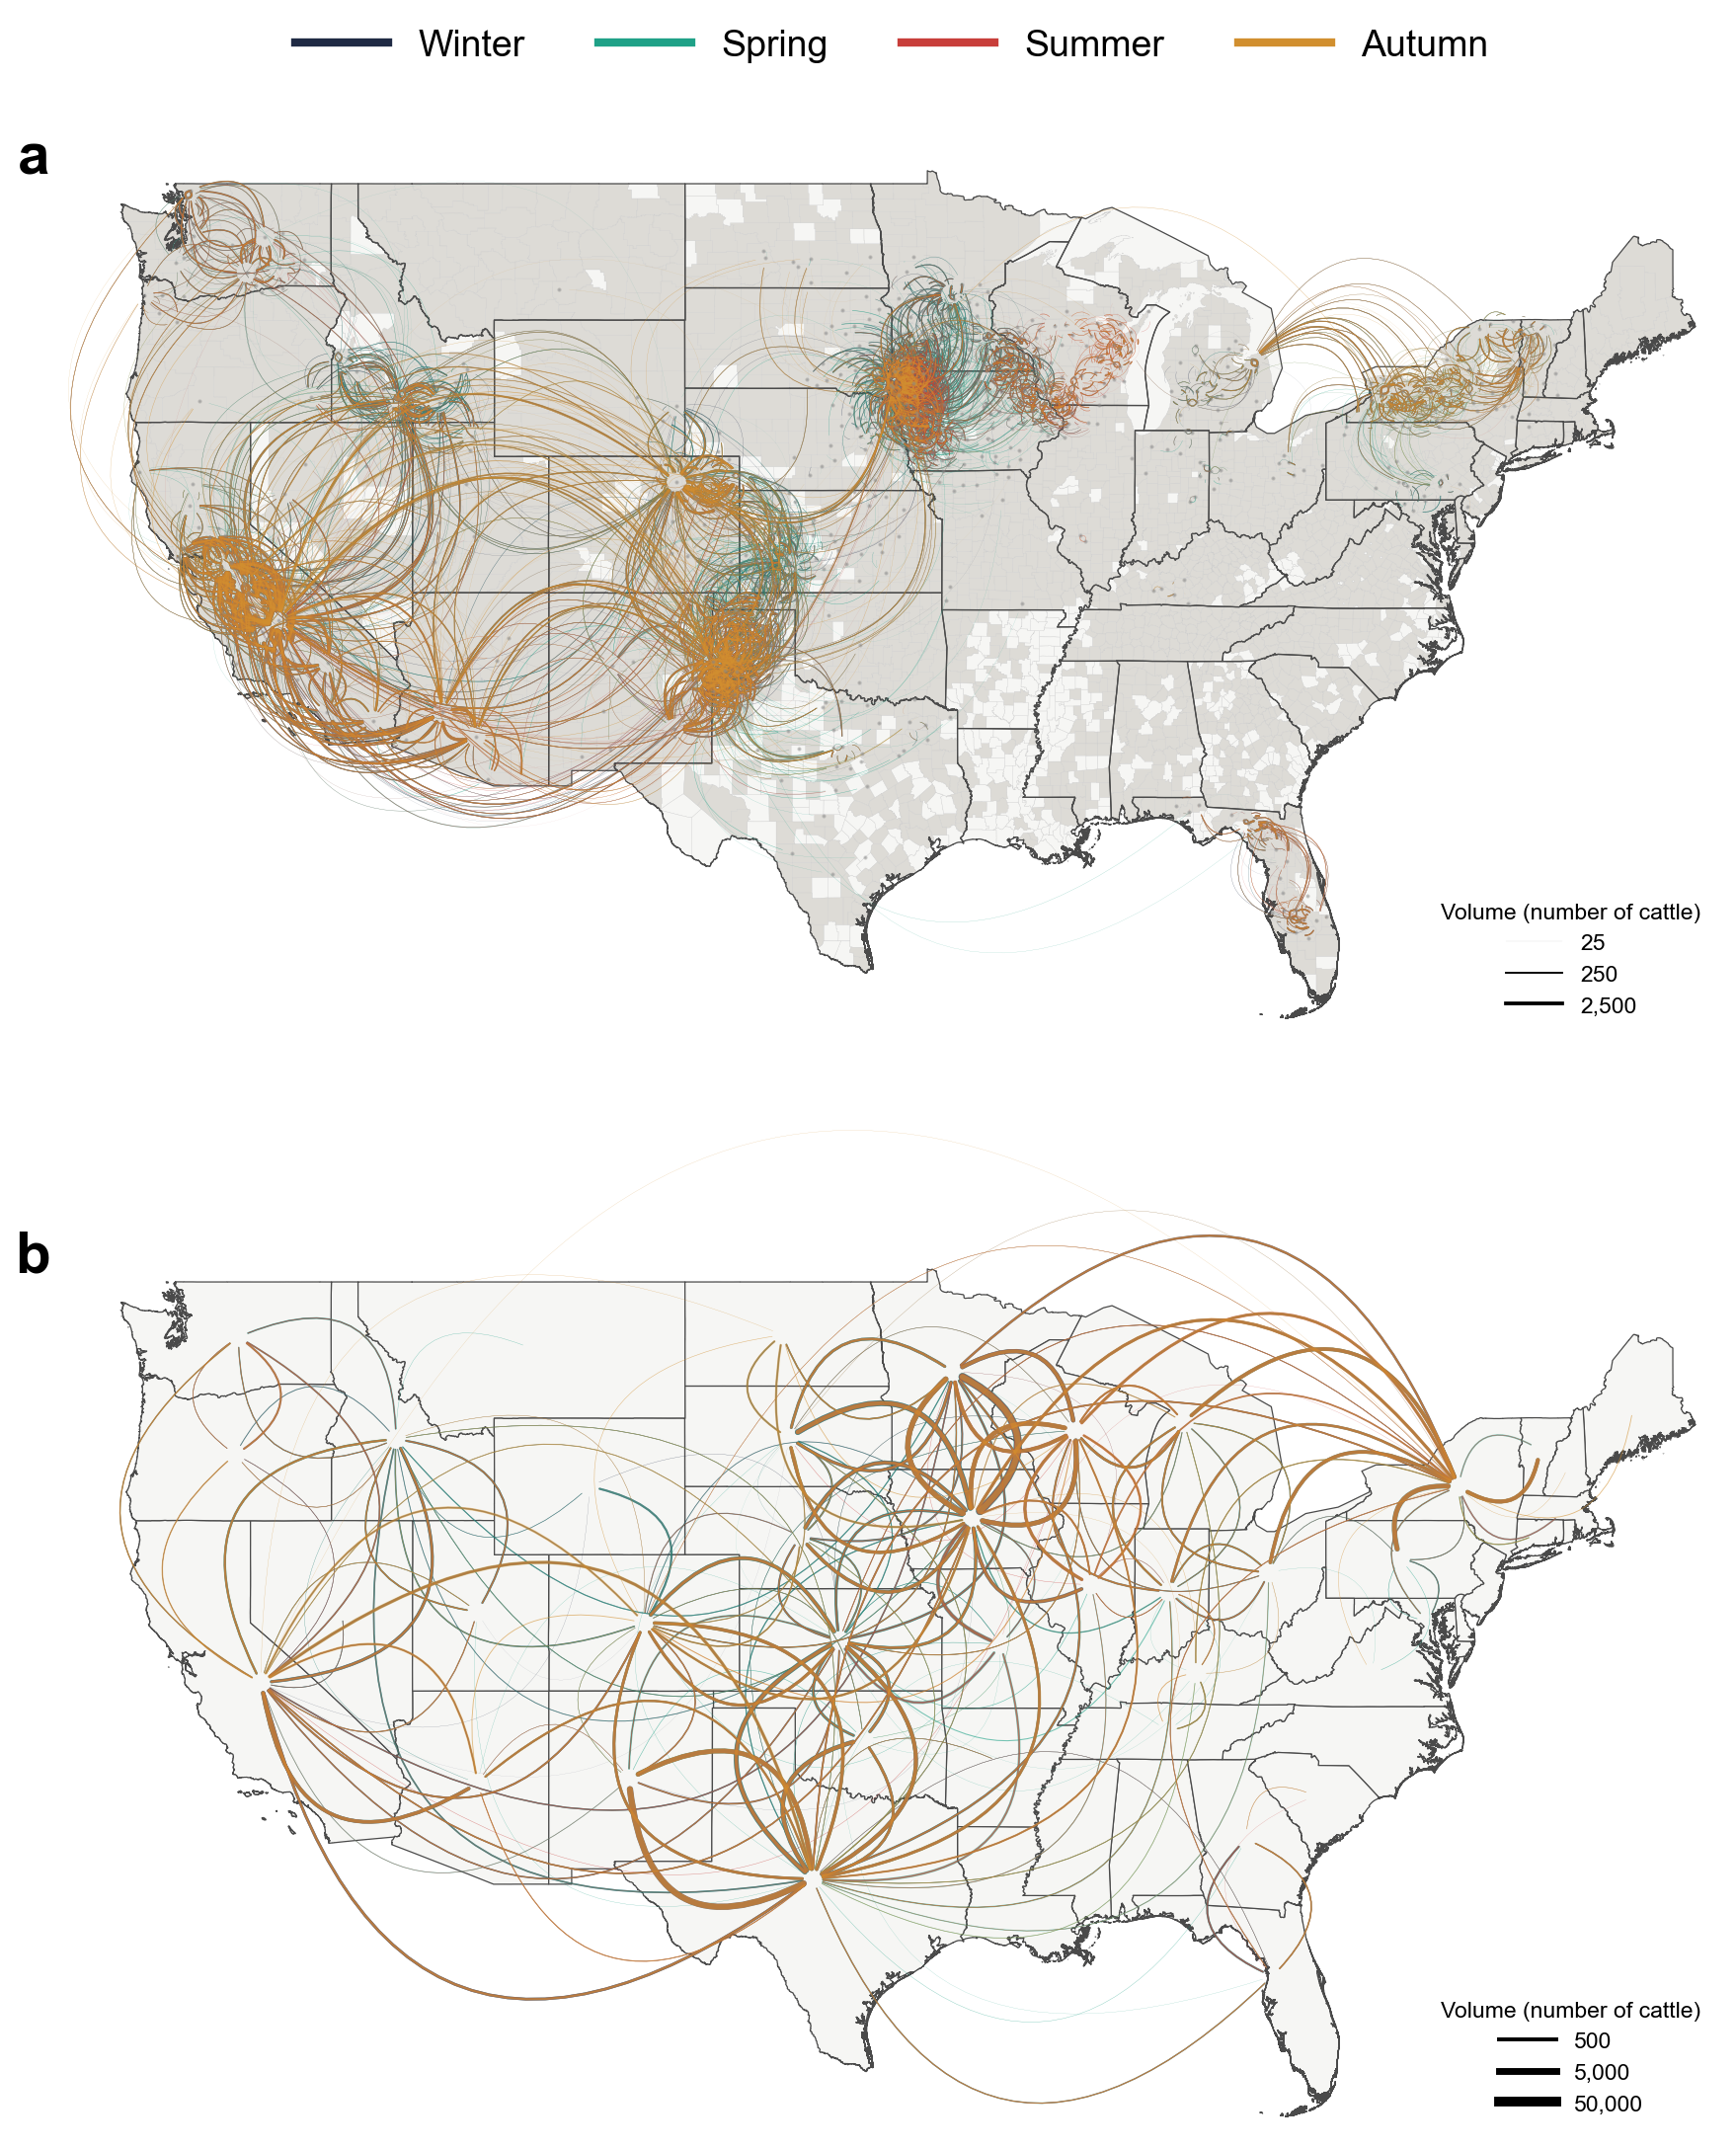

Saved S_USAMMv3maps_overlay


In [11]:
def make_thickness_legend(ax, graphs, width_scale, loc='lower right', fontsize=10, targets=[]):
    """Create a legend showing line thickness = volume mapping."""
    all_weights = []
    for G in graphs.values():
        all_weights.extend([d['weight'] for _, _, d in G.edges(data=True)])
    if not all_weights:
        return
    w_min, w_max = min(all_weights), max(all_weights)
    log_min, log_max = np.log(w_min), np.log(w_max)
    log_range = log_max - log_min if log_max > log_min else 1.0

    if not targets:
        targets = [w_min, np.exp((log_min + log_max) / 2), w_max]
    labels = [f'{v:,.0f}' for v in targets]
    widths = []
    for v in targets:
        norm = 0.01 + 0.99 * (np.log(v) - log_min) / log_range
        widths.append(norm * width_scale)

    handles = [Line2D([0], [0], color='k', lw=w, label=f'{l}')
               for w, l in zip(widths, labels)]
    ax.legend(handles=handles, loc=loc, fontsize=fontsize,
              frameon=False, handlelength=2.5, title='Volume (number of cattle)',
              title_fontsize=fontsize)

fig, axes = plt.subplots(2, 1, figsize=(14, 18))

# Panel A — county-level
ax = axes[0]
draw_basemap(ax, show_counties=True)
all_county_nodes = nx.DiGraph()
for s in SEASON_ORDER:
    draw_edges(ax, county_graphs[s], node_positions, county_widths[s],
               SEASON_COLORS[s], width_scale=2.5)
    all_county_nodes = nx.compose(all_county_nodes, county_graphs[s])
draw_nodes(ax, all_county_nodes, node_positions, size=1)
ax.text(-0.04, 1.02, 'a', transform=ax.transAxes, fontsize=28, fontweight='bold',
        va='top', ha='right')
make_thickness_legend(ax, county_graphs, width_scale=2.5, loc='lower right', fontsize=11, targets=[COUNTY_THRESHOLD, COUNTY_THRESHOLD*10, COUNTY_THRESHOLD*100])

# Panel B — state-level
ax = axes[1]
draw_basemap(ax, show_counties=False)
all_state_nodes = nx.DiGraph()
for s in SEASON_ORDER:
    draw_edges(ax, state_graphs[s], state_centroids, state_widths[s],
               SEASON_COLORS[s], width_scale=4.0)
    all_state_nodes = nx.compose(all_state_nodes, state_graphs[s])
ax.text(-0.04, 1.02, 'b', transform=ax.transAxes, fontsize=28, fontweight='bold',
        va='top', ha='right')
# make_thickness_legend(ax, state_graphs, width_scale=4.0, loc='lower right', fontsize=11)
make_thickness_legend(ax, county_graphs, width_scale=4.0, loc='lower right', fontsize=11, targets=[STATE_THRESHOLD, STATE_THRESHOLD*10, STATE_THRESHOLD*100])


# Shared season legend at top of figure, 4 columns
handles = [Line2D([0], [0], color=SEASON_COLORS[s], lw=4, label=s)
           for s in SEASON_ORDER]
fig.legend(handles=handles, loc='upper center', ncol=4, fontsize=18,
           frameon=False, handlelength=2.5,
           bbox_to_anchor=(0.5, .925))

plt.subplots_adjust(hspace=0.15)
fig.savefig(FIG_DIR / 'S_USAMMv3maps_overlay.png', dpi=300, bbox_inches='tight')
fig.savefig(FIG_DIR / 'S_USAMMv3maps_overlay.pdf', bbox_inches='tight')
plt.show()
print('Saved S_USAMMv3maps_overlay')

## Option 2: Small multiples (1×4 per level, stacked)

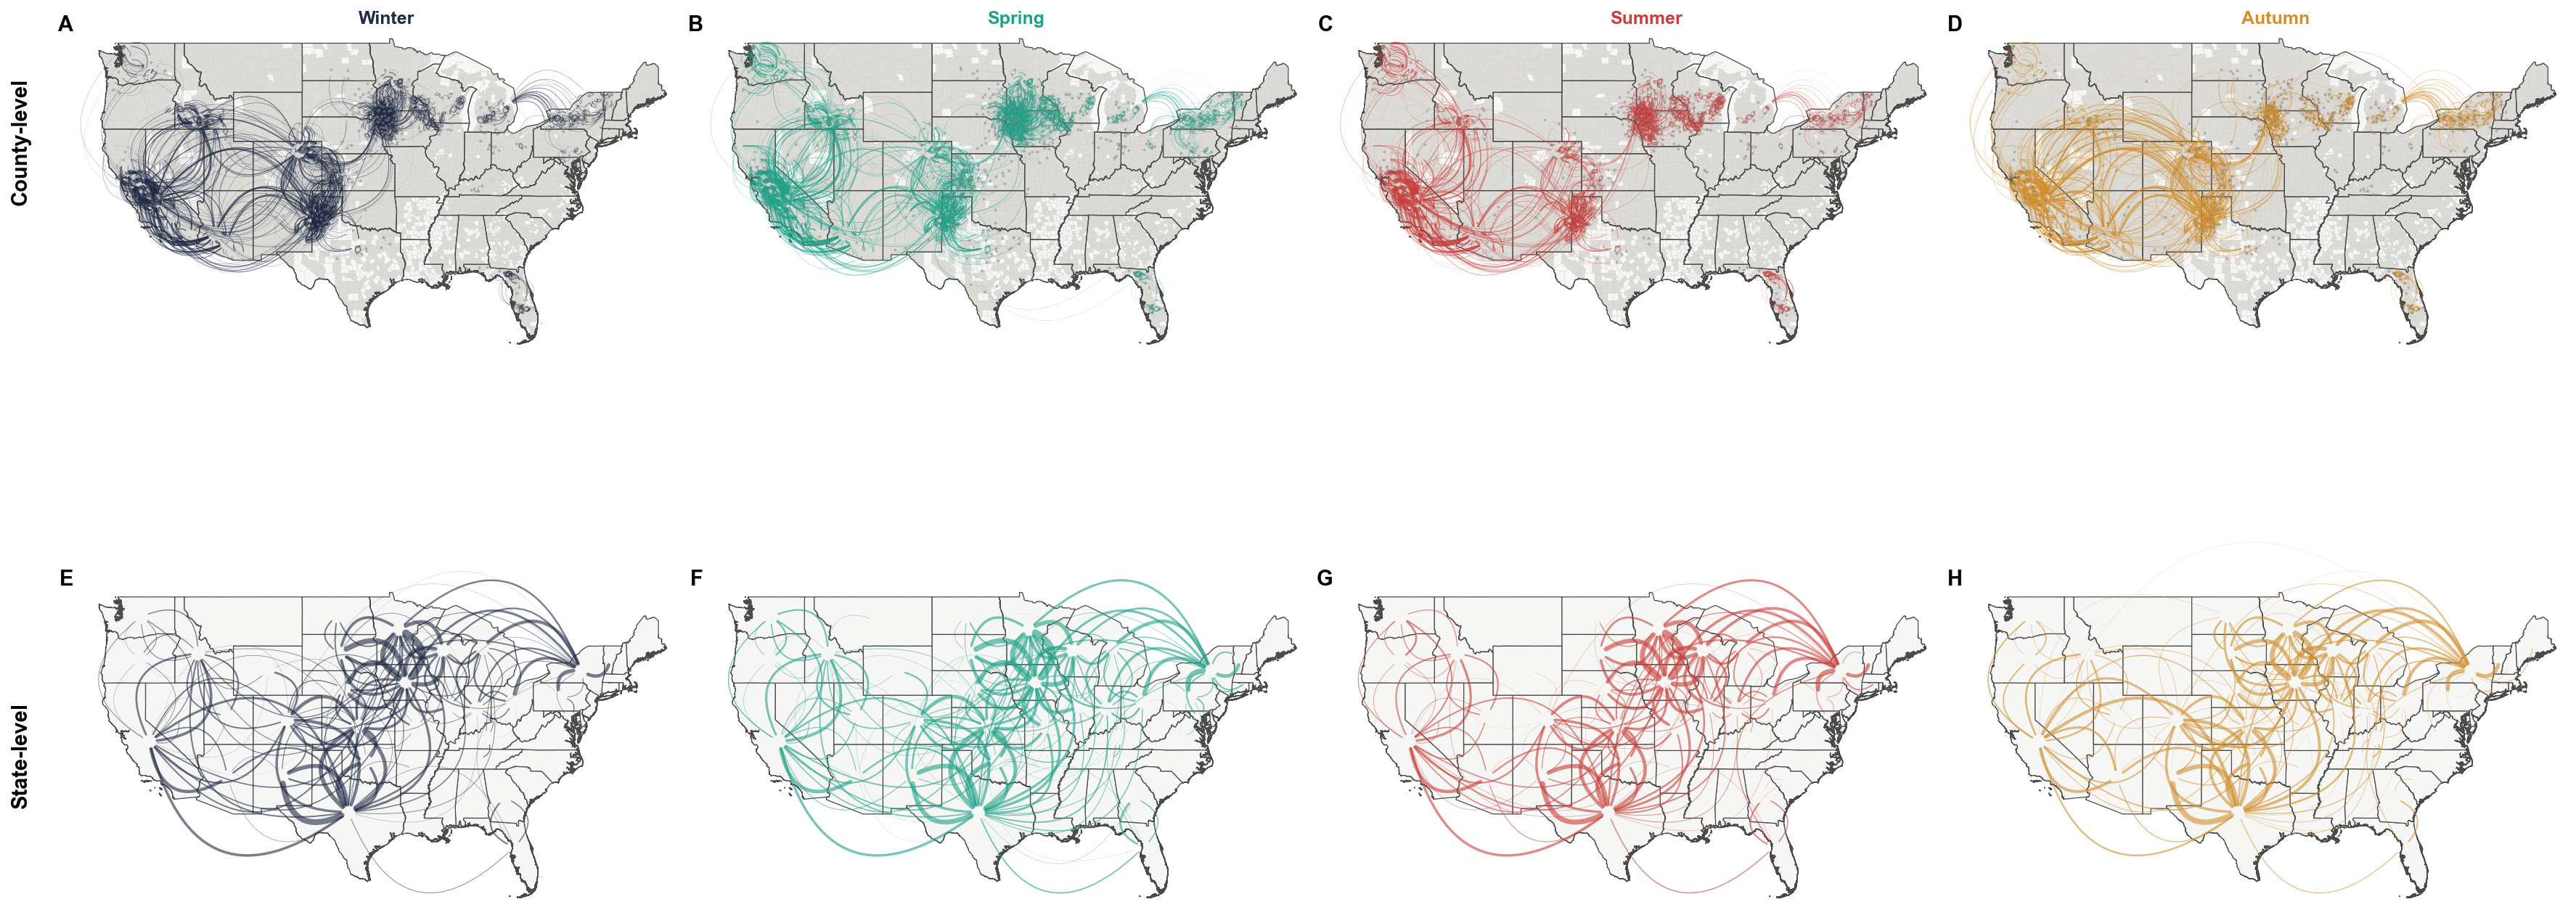

Saved S_USAMMv3maps_multiples


In [12]:
fig, axes = plt.subplots(2, 4, figsize=(24, 12))

panel_labels_top = ['A', 'B', 'C', 'D']
panel_labels_bot = ['E', 'F', 'G', 'H']

# Top row — county-level by season
for j, s in enumerate(SEASON_ORDER):
    ax = axes[0, j]
    draw_basemap(ax, show_counties=True)
    draw_edges(ax, county_graphs[s], node_positions, county_widths[s],
               SEASON_COLORS[s], width_scale=3.0, alpha=0.6)
    draw_nodes(ax, county_graphs[s], node_positions, size=1)
    ax.set_title(s, fontsize=12, fontweight='bold', color=SEASON_COLORS[s], pad=5)
    ax.text(-0.04, 1.05, panel_labels_top[j], transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='right')

# Bottom row — state-level by season
for j, s in enumerate(SEASON_ORDER):
    ax = axes[1, j]
    draw_basemap(ax, show_counties=False)
    draw_edges(ax, state_graphs[s], state_centroids, state_widths[s],
               SEASON_COLORS[s], width_scale=5.0, alpha=0.6)
    ax.text(-0.04, 1.05, panel_labels_bot[j], transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='right')

fig.text(0.02, 0.75, 'County-level', rotation=90, fontsize=14, fontweight='bold',
         va='center', ha='center')
fig.text(0.02, 0.28, 'State-level', rotation=90, fontsize=14, fontweight='bold',
         va='center', ha='center')

plt.tight_layout(rect=[0.03, 0, 1, 1])
fig.savefig(FIG_DIR / 'S_USAMMv3maps_multiples.png', dpi=300, bbox_inches='tight')
fig.savefig(FIG_DIR / 'S_USAMMv3maps_multiples.pdf', bbox_inches='tight')
plt.show()
print('Saved S_USAMMv3maps_multiples')

## Summary statistics

In [13]:
print('=== County-level (threshold = {}) ==='.format(COUNTY_THRESHOLD))
for s in SEASON_ORDER:
    total_vol = sum(county_seasonal[s].values())
    n_edges = len(county_seasonal[s])
    n_above = county_graphs[s].number_of_edges()
    print(f'  {s:8s}: {n_edges:>7,} total edges, {n_above:>6,} above threshold, '
          f'total volume = {total_vol:>12,.0f}')

print()
print('=== State-level (threshold = {}) ==='.format(STATE_THRESHOLD))
for s in SEASON_ORDER:
    total_vol = sum(state_seasonal[s].values())
    n_edges = len(state_seasonal[s])
    n_above = state_graphs[s].number_of_edges()
    print(f'  {s:8s}: {n_edges:>7,} total edges, {n_above:>6,} above threshold, '
          f'total volume = {total_vol:>12,.0f}')

=== County-level (threshold = 25) ===
  Winter  : 1,318,230 total edges,  3,296 above threshold, total volume =      863,780
  Spring  : 1,401,829 total edges,  3,964 above threshold, total volume =    1,061,599
  Summer  : 1,379,418 total edges,  3,102 above threshold, total volume =      834,781
  Autumn  : 1,287,844 total edges,  2,673 above threshold, total volume =      785,376

=== State-level (threshold = 500) ===
  Winter  :   2,240 total edges,    156 above threshold, total volume =      431,299
  Spring  :   2,246 total edges,    175 above threshold, total volume =      495,788
  Summer  :   2,250 total edges,    141 above threshold, total volume =      395,387
  Autumn  :   2,244 total edges,    142 above threshold, total volume =      365,827
